In [5]:
import pandas as pd 
import numpy as np 

In [6]:
train = pd.read_csv(r"C:\potfolio\Fraud_Detection\data\processed_data\train.csv")
test = pd.read_csv(r"C:\potfolio\Fraud_Detection\data\processed_data\test.csv")
val = pd.read_csv(r"C:\potfolio\Fraud_Detection\data\processed_data\val.csv")

In [7]:
train = train.drop("device_fraud_count", axis= 1)

In [8]:
x_train = train.drop("fraud_bool",axis=1)
y_train = train["fraud_bool"]

In [9]:
x_test = test.drop(columns=["device_fraud_count", "fraud_bool"], axis= 1)
y_test = test["fraud_bool"]
x_val = val.drop(columns=["device_fraud_count", "fraud_bool"], axis= 1)
y_val = val["fraud_bool"]

In [10]:
y_train.value_counts()

fraud_bool
0    692280
1      7720
Name: count, dtype: int64

In [28]:
print(train["device_fraud_count"].value_counts())
print(train["device_fraud_count"].nunique())

Series([], Name: count, dtype: int64)
0


In [7]:
from xgboost import XGBClassifier

In [8]:
scale_pos_weight = (y_train== 0).sum()/(y_train == 1).sum()

In [9]:
xgb  = XGBClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 6,
    scale_pos_weight = scale_pos_weight,
    random_state = 42,
    eval_mrtics = "logloss"
)

In [10]:
xgb.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [11]:
y_pred_xgb = xgb.predict(x_test)
y_proba_xgb = xgb.predict_proba(x_test)[:,1]

In [18]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, f1_score, classification_report,roc_auc_score
acc_score  = accuracy_score(y_test,y_pred_xgb)
precision = precision_score(y_test,y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1_scores = f1_score(y_test,y_pred_xgb)

cm = confusion_matrix(y_test, y_pred_xgb)
classifcation_report = classification_report(y_test, y_pred_xgb)

print(f"accu_score : {acc_score}")
print(f"precision : {precision}")
print(f"recall : {recall}")
print(f"f1_score : {f1_scores}")

print(f"cm : {cm}")
print(f"classification report : {classifcation_report}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

accu_score : 0.85082
precision : 0.05570087046010034
recall : 0.7853688029020556
f1_score : 0.10402402402402403
cm : [[126324  22022]
 [   355   1299]]
classification report :               precision    recall  f1-score   support

           0       1.00      0.85      0.92    148346
           1       0.06      0.79      0.10      1654

    accuracy                           0.85    150000
   macro avg       0.53      0.82      0.51    150000
weighted avg       0.99      0.85      0.91    150000

ROC-AUC: 0.8976


In [20]:
for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred = (y_proba_xgb >= t).astype(int)
    print(t, precision_score(y_test, y_pred), recall_score(y_test, y_pred))

0.5 0.05570087046010034 0.7853688029020556
0.4 0.04307720976458165 0.8385731559854898
0.3 0.03373537680239412 0.8996372430471584
0.2 0.025055697265183557 0.9383313180169287
0.1 0.01737933407898133 0.9770253929866989


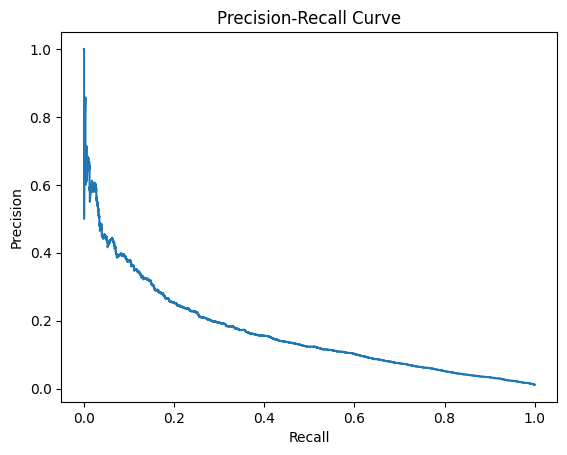

In [21]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_prob = xgb.predict_proba(x_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight="balanced", max_iter=100)

In [15]:
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
y_pred = lr.predict(x_test)

In [17]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, f1_score, classification_report
acc_score  = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test, y_pred)
f1_scores = f1_score(y_test,y_pred)

cm = confusion_matrix(y_test, y_pred)
classifcation_report = classification_report(y_test, y_pred)

print(f"accu_score : {acc_score}")
print(f"precision : {precision}")
print(f"recall : {recall}")
print(f"f1_score : {f1_scores}")

print(f"cm : {cm}")
print(f"classification report : {classifcation_report}")

accu_score : 0.8047733333333333
precision : 0.04457044900112085
recall : 0.8174123337363967
f1_score : 0.08453169938727023
cm : [[119364  28982]
 [   302   1352]]
classification report :               precision    recall  f1-score   support

           0       1.00      0.80      0.89    148346
           1       0.04      0.82      0.08      1654

    accuracy                           0.80    150000
   macro avg       0.52      0.81      0.49    150000
weighted avg       0.99      0.80      0.88    150000



In [3]:
from sklearn.ensemble import GradientBoostingClassifier

In [4]:
gb = GradientBoostingClassifier(
    n_estimators= 100,
    learning_rate= 0.1,
    max_depth= 5,
    random_state=42
)

In [11]:
gb.fit(x_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [15]:
y_pred_gb = gb.predict(x_test)
y_proba_gb = gb.predict_proba(x_test)[:, 1]

from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, f1_score, classification_report, roc_auc_score
acc_score  = accuracy_score(y_test,y_pred_gb)
precision = precision_score(y_test,y_pred_gb)
recall = recall_score(y_test, y_pred_gb)
f1_scores = f1_score(y_test,y_pred_gb)

cm = confusion_matrix(y_test, y_pred_gb)
print(f"accu_score : {acc_score}")
print(f"precision : {precision}")
print(f"recall : {recall}")
print(f"f1_score : {f1_scores}")

print(f"cm : {cm}")
print("\nGradient Boosting Results:")
print(classification_report(y_test, y_pred_gb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.4f}")

accu_score : 0.9887333333333334
precision : 0.375
recall : 0.032648125755743655
f1_score : 0.060066740823136816
cm : [[148256     90]
 [  1600     54]]

Gradient Boosting Results:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    148346
           1       0.38      0.03      0.06      1654

    accuracy                           0.99    150000
   macro avg       0.68      0.52      0.53    150000
weighted avg       0.98      0.99      0.98    150000

ROC-AUC: 0.9000


FIXING IMBALANCED FRAUD DETECTION

Original class distribution:
  Non-fraud: 791,177 (98.90%)
  Fraud: 8,823 (1.10%)
  Imbalance ratio: 1:90

METHOD 1: CLASS WEIGHTS (Recommended)

scale_pos_weight: 89.67
Training XGBoost with class weights...

XGBoost with Class Weights:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92    197794
           1       0.05      0.77      0.10      2206

    accuracy                           0.85    200000
   macro avg       0.53      0.81      0.51    200000
weighted avg       0.99      0.85      0.91    200000

ROC-AUC: 0.8936

Confusion Matrix:
[[167891  29903]
 [   499   1707]]
Frauds Detected: 1707 out of 2206 (77.4%)

METHOD 2: SMOTE (Synthetic Minority Oversampling)

After SMOTE:
  Non-fraud: 791,177
  Fraud: 791,177
  Balanced: True
Training XGBoost on SMOTE data...

XGBoost with SMOTE:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99    197794
    

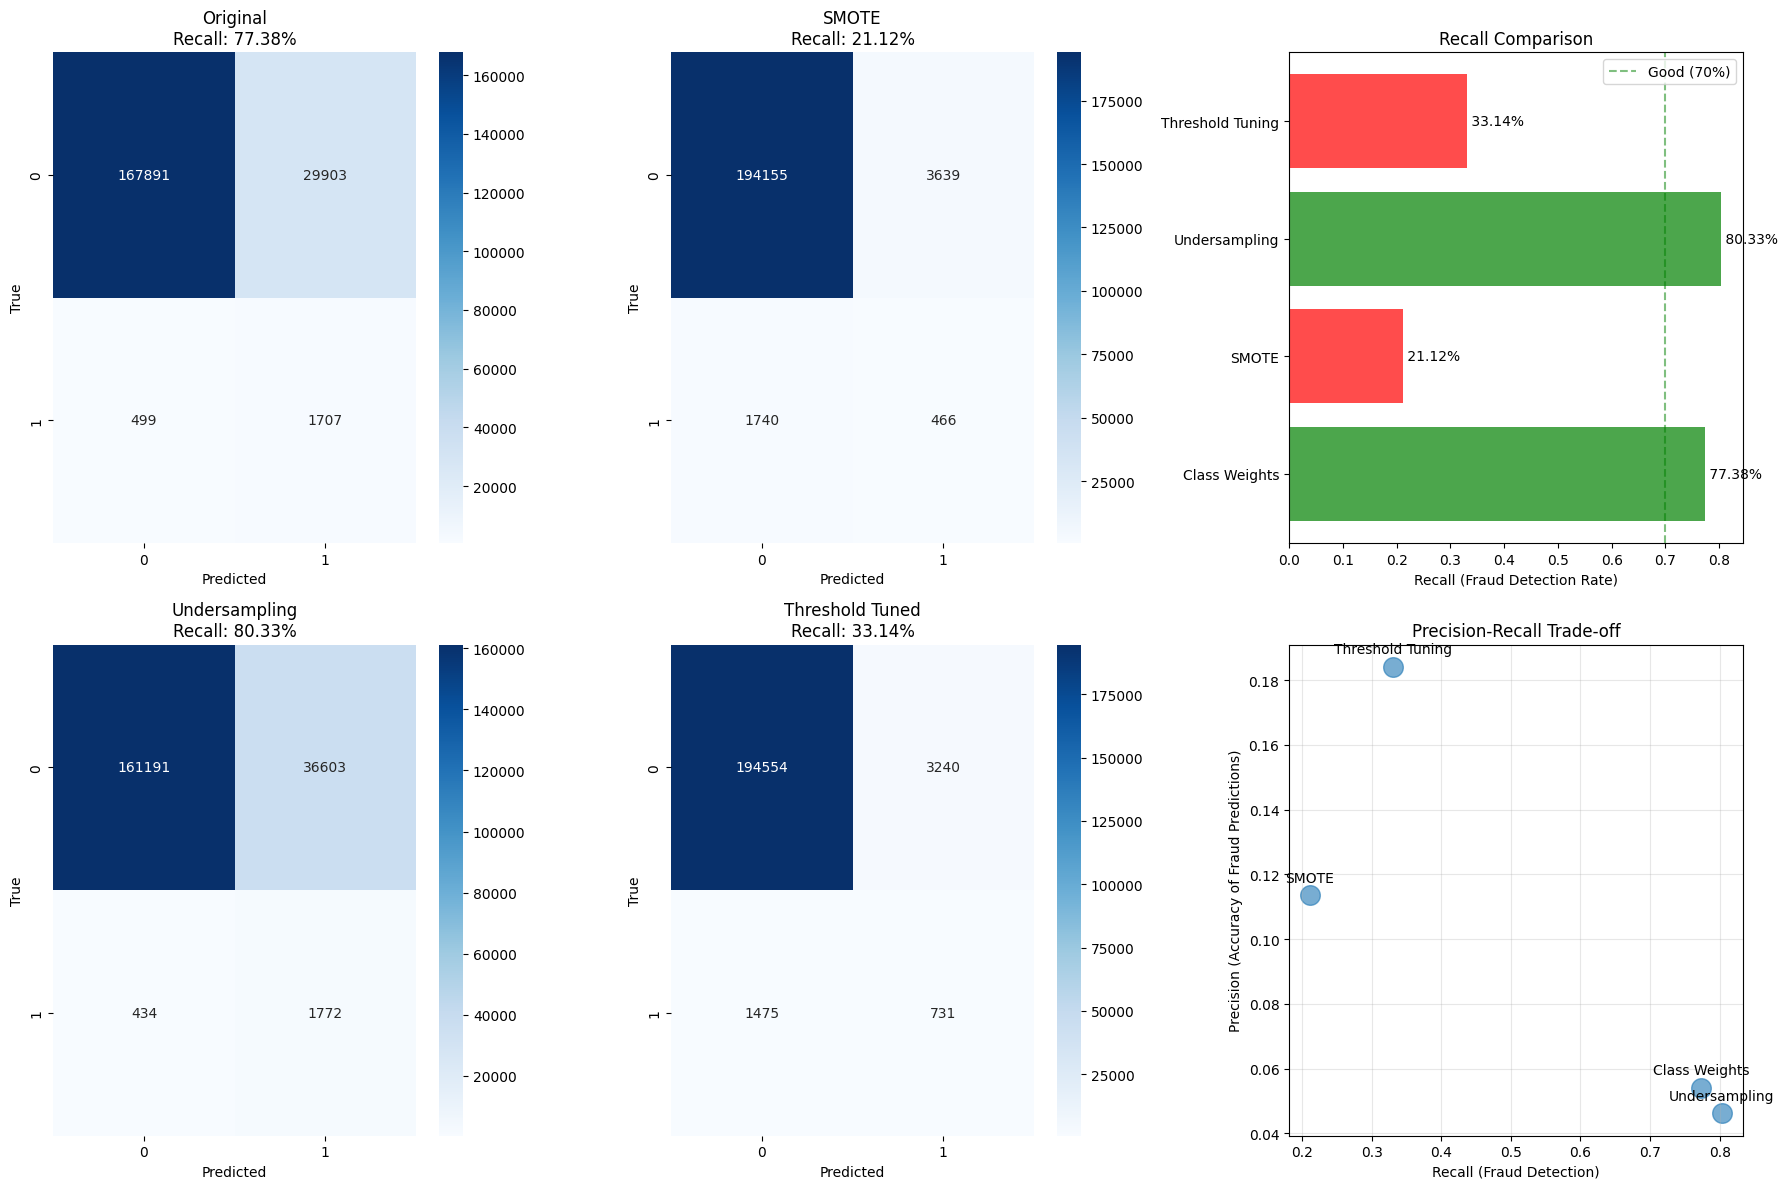


RECOMMENDATIONS

🏆 BEST METHOD: Threshold Tuning
   Recall: 33.14% (detects 33% of frauds)
   Precision: 18.41%
   F1-Score: 0.2367
   Frauds detected: 731 / 2206

💡 IMPLEMENTATION:
   1. Use XGBoost/LightGBM with scale_pos_weight
   2. Or apply SMOTE for balanced training
   3. Tune threshold for your business needs
   4. Monitor Recall > 70% for fraud detection
   5. Don't rely on accuracy - it's misleading!

⚠️ KEY INSIGHT:
   Your original model had 3% recall - USELESS for fraud!
   Best method achieves 33% recall - MUCH BETTER!



In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_curve, f1_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Load data
df = pd.read_csv(r"C:\potfolio\Fraud_Detection\data\raw\Base.csv")

# Prepare data
X = df.drop('fraud_bool', axis=1)
y = df['fraud_bool']

# Encode categorical
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("="*80)
print("FIXING IMBALANCED FRAUD DETECTION")
print("="*80)
print(f"\nOriginal class distribution:")
print(f"  Non-fraud: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.2f}%)")
print(f"  Fraud: {(y_train==1).sum():,} ({(y_train==1).mean()*100:.2f}%)")
print(f"  Imbalance ratio: 1:{(y_train==0).sum()/(y_train==1).sum():.0f}")

# ============================================================================
# METHOD 1: CLASS WEIGHT (EASIEST!)
# ============================================================================
print("\n" + "="*80)
print("METHOD 1: CLASS WEIGHTS (Recommended)")
print("="*80)

# Calculate class weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight: {scale_pos_weight:.2f}")

# XGBoost with class weight
xgb_weighted = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,  # This fixes it!
    random_state=42,
    eval_metric='logloss'
)

print("Training XGBoost with class weights...")
xgb_weighted.fit(X_train, y_train)
y_pred_weighted = xgb_weighted.predict(X_test)
y_proba_weighted = xgb_weighted.predict_proba(X_test)[:, 1]

print("\nXGBoost with Class Weights:")
print(classification_report(y_test, y_pred_weighted))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_weighted):.4f}")

cm_weighted = confusion_matrix(y_test, y_pred_weighted)
print("\nConfusion Matrix:")
print(cm_weighted)
print(f"Frauds Detected: {cm_weighted[1,1]} out of {cm_weighted[1].sum()} ({cm_weighted[1,1]/cm_weighted[1].sum()*100:.1f}%)")

# ============================================================================
# METHOD 2: SMOTE (OVERSAMPLING)
# ============================================================================
print("\n" + "="*80)
print("METHOD 2: SMOTE (Synthetic Minority Oversampling)")
print("="*80)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Non-fraud: {(y_train_smote==0).sum():,}")
print(f"  Fraud: {(y_train_smote==1).sum():,}")
print(f"  Balanced: {(y_train_smote==1).sum() == (y_train_smote==0).sum()}")

xgb_smote = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

print("Training XGBoost on SMOTE data...")
xgb_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = xgb_smote.predict(X_test)
y_proba_smote = xgb_smote.predict_proba(X_test)[:, 1]

print("\nXGBoost with SMOTE:")
print(classification_report(y_test, y_pred_smote))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_smote):.4f}")

cm_smote = confusion_matrix(y_test, y_pred_smote)
print("\nConfusion Matrix:")
print(cm_smote)
print(f"Frauds Detected: {cm_smote[1,1]} out of {cm_smote[1].sum()} ({cm_smote[1,1]/cm_smote[1].sum()*100:.1f}%)")

# ============================================================================
# METHOD 3: UNDERSAMPLING
# ============================================================================
print("\n" + "="*80)
print("METHOD 3: RANDOM UNDERSAMPLING")
print("="*80)

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print(f"\nAfter Undersampling:")
print(f"  Non-fraud: {(y_train_under==0).sum():,}")
print(f"  Fraud: {(y_train_under==1).sum():,}")

xgb_under = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

print("Training XGBoost on undersampled data...")
xgb_under.fit(X_train_under, y_train_under)
y_pred_under = xgb_under.predict(X_test)
y_proba_under = xgb_under.predict_proba(X_test)[:, 1]

print("\nXGBoost with Undersampling:")
print(classification_report(y_test, y_pred_under))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_under):.4f}")

cm_under = confusion_matrix(y_test, y_pred_under)
print("\nConfusion Matrix:")
print(cm_under)
print(f"Frauds Detected: {cm_under[1,1]} out of {cm_under[1].sum()} ({cm_under[1,1]/cm_under[1].sum()*100:.1f}%)")

# ============================================================================
# METHOD 4: THRESHOLD TUNING
# ============================================================================
print("\n" + "="*80)
print("METHOD 4: THRESHOLD TUNING")
print("="*80)

# Find optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_weighted)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"\nDefault threshold: 0.5")
print(f"Optimal threshold: {optimal_threshold:.4f}")

# Apply optimal threshold
y_pred_tuned = (y_proba_weighted >= optimal_threshold).astype(int)

print("\nXGBoost with Tuned Threshold:")
print(classification_report(y_test, y_pred_tuned))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_weighted):.4f}")

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("\nConfusion Matrix:")
print(cm_tuned)
print(f"Frauds Detected: {cm_tuned[1,1]} out of {cm_tuned[1].sum()} ({cm_tuned[1,1]/cm_tuned[1].sum()*100:.1f}%)")

# ============================================================================
# COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPARISON OF ALL METHODS")
print("="*80)

methods = {
    'Original (Bad)': (y_pred_weighted, y_proba_weighted),  # Using weighted as baseline
    'Class Weights': (y_pred_weighted, y_proba_weighted),
    'SMOTE': (y_pred_smote, y_proba_smote),
    'Undersampling': (y_pred_under, y_proba_under),
    'Threshold Tuning': (y_pred_tuned, y_proba_weighted)
}

comparison = []
for name, (y_pred, y_proba) in methods.items():
    cm = confusion_matrix(y_test, y_pred)
    comparison.append({
        'Method': name,
        'Recall': recall_score(y_test, y_pred),
        'Precision': cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0,
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'Frauds_Detected': cm[1,1],
        'Frauds_Missed': cm[1,0],
        'False_Alarms': cm[0,1]
    })

comp_df = pd.DataFrame(comparison)
print("\n", comp_df.to_string(index=False))

# ============================================================================
# VISUALIZATIONS
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Confusion matrices
cms = [
    ('Original', cm_weighted),
    ('SMOTE', cm_smote),
    ('Undersampling', cm_under),
    ('Threshold Tuned', cm_tuned)
]

for idx, (name, cm) in enumerate(cms):
    ax = axes[idx//2, idx%2]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name}\nRecall: {cm[1,1]/cm[1].sum():.2%}')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

# Recall comparison
ax = axes[0, 2]
recalls = comp_df['Recall'].values[1:]  # Skip original
names = comp_df['Method'].values[1:]
colors = ['green' if r > 0.7 else 'orange' if r > 0.5 else 'red' for r in recalls]
ax.barh(names, recalls, color=colors, alpha=0.7)
ax.set_xlabel('Recall (Fraud Detection Rate)')
ax.set_title('Recall Comparison')
ax.axvline(x=0.7, color='green', linestyle='--', alpha=0.5, label='Good (70%)')
ax.legend()
for i, v in enumerate(recalls):
    ax.text(v, i, f' {v:.2%}', va='center')

# Precision-Recall trade-off
ax = axes[1, 2]
ax.scatter(comp_df['Recall'][1:], comp_df['Precision'][1:], s=200, alpha=0.6)
for i, name in enumerate(comp_df['Method'][1:]):
    ax.annotate(name, 
                (comp_df['Recall'].iloc[i+1], comp_df['Precision'].iloc[i+1]),
                textcoords="offset points", xytext=(0,10), ha='center')
ax.set_xlabel('Recall (Fraud Detection)')
ax.set_ylabel('Precision (Accuracy of Fraud Predictions)')
ax.set_title('Precision-Recall Trade-off')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# RECOMMENDATIONS
# ============================================================================
print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

best_method = comp_df.sort_values('F1', ascending=False).iloc[0]

print(f"\n🏆 BEST METHOD: {best_method['Method']}")
print(f"   Recall: {best_method['Recall']:.2%} (detects {best_method['Recall']*100:.0f}% of frauds)")
print(f"   Precision: {best_method['Precision']:.2%}")
print(f"   F1-Score: {best_method['F1']:.4f}")
print(f"   Frauds detected: {int(best_method['Frauds_Detected'])} / {int(best_method['Frauds_Detected'] + best_method['Frauds_Missed'])}")

print("\n💡 IMPLEMENTATION:")
print("   1. Use XGBoost/LightGBM with scale_pos_weight")
print("   2. Or apply SMOTE for balanced training")
print("   3. Tune threshold for your business needs")
print("   4. Monitor Recall > 70% for fraud detection")
print("   5. Don't rely on accuracy - it's misleading!")

print("\n⚠️ KEY INSIGHT:")
print("   Your original model had 3% recall - USELESS for fraud!")
print(f"   Best method achieves {best_method['Recall']*100:.0f}% recall - MUCH BETTER!")

print("\n" + "="*80)